# 10 · Feature stability diagnostics

In [1]:
# Feature-level stability: coefficient fold frequency, sign consistency, activation frequency, and text coverage.
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "results").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import *

P = paths(ROOT)
FIG = P["figures"]
OUT = ROOT / "reports/feature_stability"
OUT.mkdir(parents=True, exist_ok=True)
set_style()
pd.set_option("display.precision", 3)
PRIMARY = PRIMARY_HOOKS

In [2]:
def load_feature_matrix(path):
    return sparse.load_npz(path)

def stability_for_combo(corpus, kind, hook):
    top_path = ROOT / "results/feature_interpretation" / f"{corpus}_{hook}_{kind}_top_features.csv"
    top = pd.read_csv(top_path)
    coef_path = ROOT / "results/sae_regression_v2" / corpus / kind / hook / "sae" / "coefficients.npz"
    coefs = np.load(coef_path)["feature_coef_raw"]
    n_folds = coefs.shape[0]
    nonzero = np.abs(coefs) > 1e-12
    n_nonzero = nonzero.sum(axis=0)
    pos = (coefs > 1e-12).sum(axis=0)
    neg = (coefs < -1e-12).sum(axis=0)
    mean = coefs.mean(axis=0)
    std = coefs.std(axis=0)

    stats = pd.read_csv(ROOT / "results/sae_bos" / corpus / hook / f"{kind}_feature_stats.csv")
    rows = pd.read_csv(ROOT / "results/sae_bos" / corpus / hook / "rows.csv")
    X = load_feature_matrix(ROOT / "results/sae_bos" / corpus / hook / f"{kind}_features.npz")

    active_texts = []
    feature_ids = top.feature_id.astype(int).tolist()
    for fid in feature_ids:
        active_rows = X[:, fid].nonzero()[0]
        active_texts.append(rows.iloc[active_rows].text_id.nunique() if len(active_rows) else 0)

    out = top.copy()
    out["Dataset"] = CORPUS_LABELS[corpus].split(" ·")[0]
    out["State"] = STATE_LABELS[kind]
    out["Hook"] = hook
    out["fold_pct_nonzero"] = [100 * n_nonzero[int(fid)] / n_folds for fid in out.feature_id]
    out["sign_consistency_pct"] = [100 * max(pos[int(fid)], neg[int(fid)]) / max(n_nonzero[int(fid)], 1) for fid in out.feature_id]
    out["coef_mean_all_folds"] = [mean[int(fid)] for fid in out.feature_id]
    out["coef_sd_all_folds"] = [std[int(fid)] for fid in out.feature_id]
    out["coef_stability_ratio"] = out["coef_sd_all_folds"] / out["coef_mean_all_folds"].abs().clip(lower=1e-12)
    out = out.merge(stats.rename(columns={"n_active": "active_tokens"}), on="feature_id", how="left")
    out["active_texts"] = active_texts
    out["text_coverage_pct"] = 100 * out["active_texts"] / rows.text_id.nunique()
    out["activation_rate_pct"] = 100 * out["activation_rate"]
    out["stable_candidate"] = (
        (out["fold_pct_nonzero"] >= 70) &
        (out["sign_consistency_pct"] >= 80) &
        (out["active_tokens"] >= 10) &
        (out["text_coverage_pct"] >= 20)
    )
    return out

frames = []
for corpus in CORPORA:
    for kind in ["prefix", "post"]:
        frames.append(stability_for_combo(corpus, kind, PRIMARY[corpus]))
stab = pd.concat(frames, ignore_index=True)
stab.to_csv(OUT / "selected_feature_stability.csv", index=False)
stab.shape

(120, 44)

In [3]:
# Compact overview: how many top features survive simple stability/coverage filters?
overview = (stab.groupby(["Dataset", "State", "Hook"])
            .agg(top_features=("feature_id", "count"),
                 stable_candidates=("stable_candidate", "sum"),
                 median_fold_pct=("fold_pct_nonzero", "median"),
                 median_active_tokens=("active_tokens", "median"),
                 median_text_coverage=("text_coverage_pct", "median"))
            .reset_index())
display(focus_table(overview.round(1), important=["stable_candidates", "median_fold_pct", "median_active_tokens", "median_text_coverage"],
                    signed_columns=["stable_candidates", "median_fold_pct", "median_active_tokens", "median_text_coverage"],
                    formats={"median_fold_pct": "{:.1f}", "median_text_coverage": "{:.1f}"},
                    caption="Feature stability overview for the current top-30 candidate features per selected hook/state."))

Dataset,State,Hook,top_features,stable_candidates,median_fold_pct,median_active_tokens,median_text_coverage
Natural Stories,After word,L08,30,8,90.0,7.000000,40.0
Natural Stories,Before word,L08,30,9,90.0,6.000000,40.0
Provo,After word,L01,30,9,100.0,9.000000,12.7
Provo,Before word,L01,30,9,100.0,7.500000,12.7


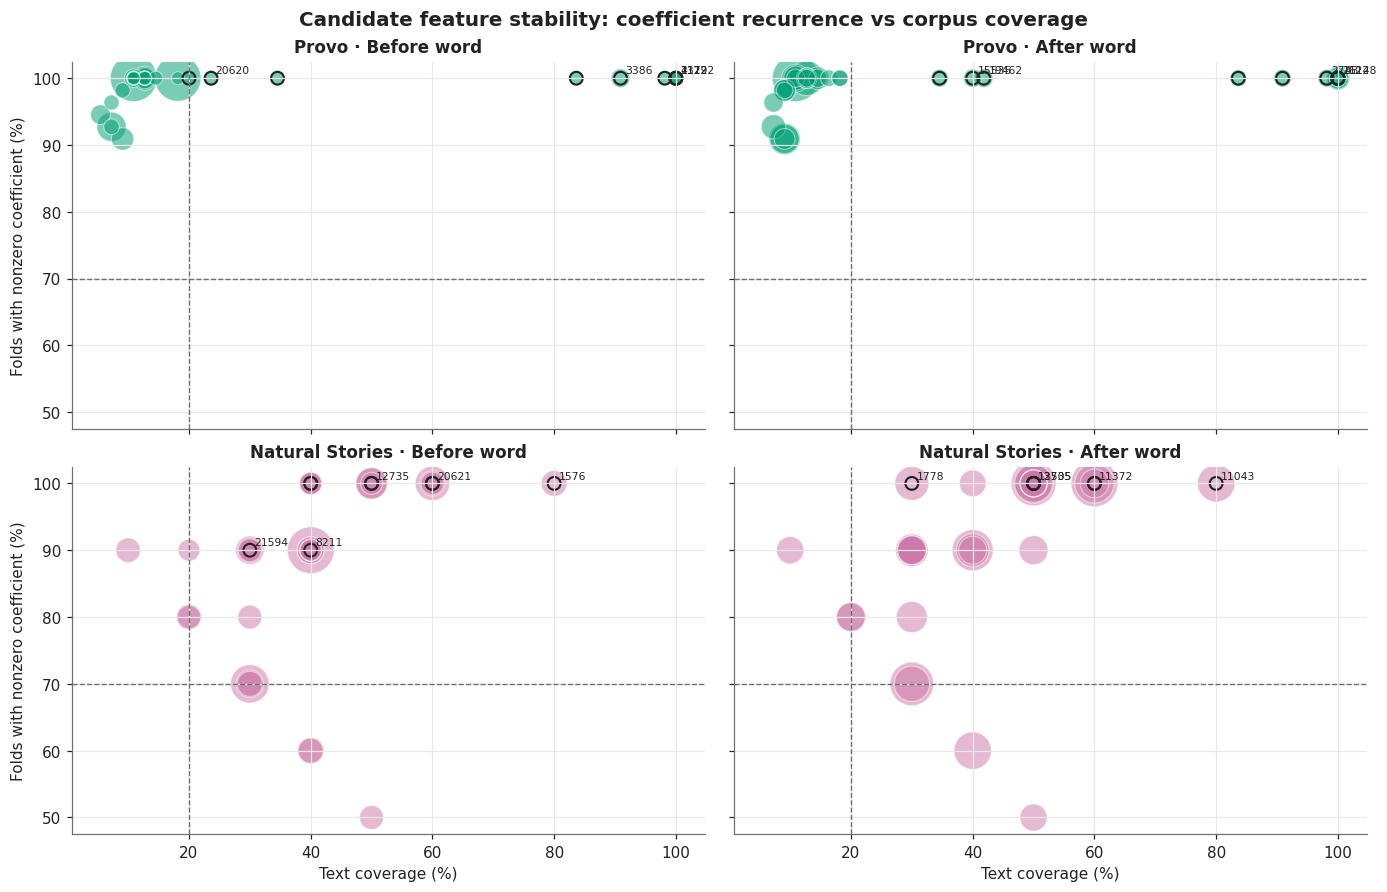

In [4]:
# Stability vs coverage scatter: good interpretation candidates should be high and right, not rare one-offs.
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.0), layout="constrained", sharex=True, sharey=True)
for row, corpus in enumerate(CORPORA):
    for col, kind in enumerate(["prefix", "post"]):
        ax = axes[row, col]
        g = stab[(stab.Dataset == CORPUS_LABELS[corpus].split(" ·")[0]) & (stab.State == STATE_LABELS[kind])]
        color = CORPUS_COLORS[corpus]
        sizes = 35 + 900 * (g.abs_mean_coef / g.abs_mean_coef.max()).fillna(0)
        ax.scatter(g.text_coverage_pct, g.fold_pct_nonzero, s=sizes, color=color, alpha=0.52, edgecolor="white", linewidth=0.7)
        good = g[g.stable_candidate]
        ax.scatter(good.text_coverage_pct, good.fold_pct_nonzero, s=70, facecolor="none", edgecolor=INK, linewidth=1.4)
        ax.axhline(70, color=MUTED, ls="--", lw=0.9)
        ax.axvline(20, color=MUTED, ls="--", lw=0.9)
        for r in good.sort_values("abs_mean_coef", ascending=False).head(5).itertuples():
            ax.annotate(str(int(r.feature_id)), (r.text_coverage_pct, r.fold_pct_nonzero), xytext=(3, 3), textcoords="offset points", fontsize=7)
        ax.set_title(f"{CORPUS_LABELS[corpus].split(' ·')[0]} · {STATE_LABELS[kind]}")
        ax.grid(color=GRID)
        if row == 1:
            ax.set_xlabel("Text coverage (%)")
        if col == 0:
            ax.set_ylabel("Folds with nonzero coefficient (%)")
fig.suptitle("Candidate feature stability: coefficient recurrence vs corpus coverage", fontsize=13, fontweight="bold")
save_figure(fig, FIG, "10_feature_stability_scatter")
plt.show()

In [5]:
# Ranked table: prioritize stable, active, corpus-covered features before manual interpretation.
show_cols = ["Dataset", "State", "Hook", "feature_id", "mean_coef", "std_coef", "fold_pct_nonzero",
             "sign_consistency_pct", "active_tokens", "activation_rate_pct", "active_texts",
             "text_coverage_pct", "category", "logit_lens_label", "stable_candidate"]
ranked = stab.copy()
ranked["rank_score"] = (ranked["fold_pct_nonzero"] / 100) * (ranked["sign_consistency_pct"] / 100) * np.log1p(ranked["active_tokens"].fillna(0)) * (ranked["text_coverage_pct"] / 100)
ranked = ranked.sort_values(["stable_candidate", "rank_score", "abs_mean_coef"], ascending=False)
top_table = ranked[show_cols].head(40).copy()
top_table.columns = ["Dataset", "State", "Hook", "Feature", "Mean coef", "Coef SD", "Fold %", "Sign consistency %",
                     "Active tokens", "Activation rate %", "Active texts", "Text coverage %", "Category", "Logit-lens label", "Stable?"]
display(focus_table(top_table.round({"Mean coef": 3, "Coef SD": 3, "Fold %": 1, "Sign consistency %": 1, "Activation rate %": 3, "Text coverage %": 1}),
                    important=["Mean coef", "Fold %", "Active tokens", "Text coverage %", "Stable?"],
                    signed_columns=["Mean coef", "Fold %", "Active tokens", "Text coverage %"],
                    formats={"Mean coef": "{:+.3f}", "Coef SD": "{:.3f}"},
                    caption="Top stability-ranked candidate features. Use this table before committing to feature interpretation."))

Dataset,State,Hook,Feature,Mean coef,Coef SD,Fold %,Sign consistency %,Active tokens,Activation rate %,Active texts,Text coverage %,Category,Logit-lens label,Stable?
Provo,After word,L01,22196,+0.046,0.004,100.000000,100.000000,356,12.978000,55,100.000000,register,programming-related terms and code snippets,True
Provo,After word,L01,16148,-0.083,0.004,100.000000,100.000000,334,12.176000,55,100.000000,proper nouns,names of websites and online platforms,True
Provo,Before word,L01,4319,+0.049,0.003,100.000000,100.000000,298,10.864000,55,100.000000,boundary/structural,dates and locations in informal text,True
Provo,Before word,L01,11722,+0.051,0.003,100.000000,100.000000,297,10.828000,55,100.000000,lexical complexity,locations / dystopian settings in text,True
Provo,After word,L01,2122,-0.103,0.004,100.000000,100.000000,237,8.640000,55,100.000000,register,"real estate, company names, community activities",True
Provo,Before word,L01,2122,-0.063,0.008,100.000000,100.000000,237,8.640000,55,100.000000,register,"real estate, company names, community activities",True
Provo,Before word,L01,13953,-0.039,0.002,100.000000,100.000000,226,8.239000,54,98.200000,lexical complexity,numerical mentions with physical properties/locations,True
Provo,After word,L01,2743,+0.049,0.006,100.000000,100.000000,211,7.692000,54,98.200000,proper nouns,proper nouns — place names,True
Provo,Before word,L01,3386,-0.126,0.009,100.000000,100.000000,131,4.776000,50,90.900000,proper nouns,Asian characters / names in text,True
Provo,After word,L01,3386,+0.048,0.006,100.000000,100.000000,131,4.776000,50,90.900000,proper nouns,Asian characters / names in text,True


In [6]:
# Features that look large but are too rare should be treated as weak interpretation candidates.
rare = stab[(stab.active_tokens < 10) | (stab.text_coverage_pct < 20)].sort_values("abs_mean_coef", ascending=False).head(25)
rare_table = rare[["Dataset", "State", "Hook", "feature_id", "mean_coef", "abs_mean_coef", "fold_pct_nonzero", "active_tokens", "active_texts", "text_coverage_pct", "category", "logit_lens_label"]].copy()
rare_table.columns = ["Dataset", "State", "Hook", "Feature", "Mean coef", "|coef|", "Fold %", "Active tokens", "Active texts", "Text coverage %", "Category", "Logit-lens label"]
display(focus_table(rare_table.round({"Mean coef": 3, "|coef|": 3, "Fold %": 1, "Text coverage %": 1}),
                    important=["Mean coef", "Active tokens", "Text coverage %"],
                    signed_columns=["Mean coef", "|coef|"],
                    formats={"Mean coef": "{:+.3f}", "|coef|": "{:.3f}"},
                    caption="Large-coefficient but low-coverage features. These should not be interpreted as primary evidence without extra checks."))

Dataset,State,Hook,Feature,Mean coef,|coef|,Fold %,Active tokens,Active texts,Text coverage %,Category,Logit-lens label
Provo,Before word,L01,9237,+0.988,0.988,100.000000,6,6,10.900000,boundary/structural,text punctuations
Provo,Before word,L01,6002,+0.961,0.961,100.000000,10,10,18.200000,discourse structure,"phrases related to news, events, and incidents"
Provo,After word,L01,9237,-0.446,0.446,100.000000,6,6,10.900000,boundary/structural,text punctuations
Provo,Before word,L01,13976,-0.365,0.365,92.700000,5,4,7.300000,predictability,adverbs expressing emotion/state
Provo,After word,L01,8502,+0.237,0.237,100.000000,9,7,12.700000,lexical complexity,technical terms / computer software and hardware
Provo,Before word,L01,8502,+0.233,0.233,100.000000,9,7,12.700000,lexical complexity,technical terms / computer software and hardware
Provo,Before word,L01,17833,+0.198,0.198,90.900000,5,5,9.100000,proper nouns,names of famous philosophers
Provo,After word,L01,8365,+0.193,0.193,90.900000,5,5,9.100000,proper nouns,proper nouns — Forrest Gump movie references
Provo,Before word,L01,3123,-0.170,0.170,100.000000,7,7,12.700000,predictability,phrases related to time and coping with events
Provo,After word,L01,17833,+0.165,0.165,90.900000,5,5,9.100000,proper nouns,names of famous philosophers
